<a href="https://colab.research.google.com/github/tphan356/ai-restaurant-calling-agent/blob/main/notebooks/01_train_intent_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/tphan356/ai-restaurant-calling-agent/main/data/ai_calling_agent_dataset_1000.csv")
df.head()

,text,intent,time,food_item,location
0,"Hi, Order food for me right now",order,9 PM,pasta,main road
1,"Hi, Hi quickly",greeting,6 PM,sandwich,near mall
2,"Hello, Table for 4 at 8 PM right now",reservation,8 PM,pasta,downtown
3,Hi please,greeting,7 PM,burger,main road
4,"Hey, What are your timings?",query,9 PM,pizza,downtown


In [13]:
# Check the data
print(f"Data Shape : {df.shape}")
print(f"Columns : {df.columns}")
print(f"Unique Intents : {df['intent'].nunique()} -> {df['intent'].unique().tolist()}")
print(f"Missing Values : \n{df.isnull().sum()}")

Data Shape : (1200, 5)
Columns : Index(['text', 'intent', 'time', 'food_item', 'location'], dtype='object')
Unique Intents : 6 -> ['order', 'greeting', 'reservation', 'query', 'complaint', 'cancel']
Missing Values : 
text         0
intent       0
time         0
food_item    0
location     0
dtype: int64


In [15]:
# Clean the data
df = df.dropna(subset=['text', 'intent'])
df["text"] = df["text"].astype(str)
df['intent'] = df['intent'].astype(str)

df = df.drop_duplicates()
df.head()

,text,intent,time,food_item,location
0,"Hi, Order food for me right now",order,9 PM,pasta,main road
1,"Hi, Hi quickly",greeting,6 PM,sandwich,near mall
2,"Hello, Table for 4 at 8 PM right now",reservation,8 PM,pasta,downtown
3,Hi please,greeting,7 PM,burger,main road
4,"Hey, What are your timings?",query,9 PM,pizza,downtown


In [16]:
# Train/test split
X = df['text']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Baseline model
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2)
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [18]:
# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Std CV Accuracy:", np.std(cv_scores))

CV Accuracy Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0
Std CV Accuracy: 0.0


In [19]:
#Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [21]:
#Evaluate
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[39  0  0  0  0  0]
 [ 0 36  0  0  0  0]
 [ 0  0 42  0  0  0]
 [ 0  0  0 41  0  0]
 [ 0  0  0  0 40  0]
 [ 0  0  0  0  0 40]]
Classification Report:
               precision    recall  f1-score   support

      cancel       1.00      1.00      1.00        39
   complaint       1.00      1.00      1.00        36
    greeting       1.00      1.00      1.00        42
       order       1.00      1.00      1.00        41
       query       1.00      1.00      1.00        40
 reservation       1.00      1.00      1.00        40

    accuracy                           1.00       238
   macro avg       1.00      1.00      1.00       238
weighted avg       1.00      1.00      1.00       238



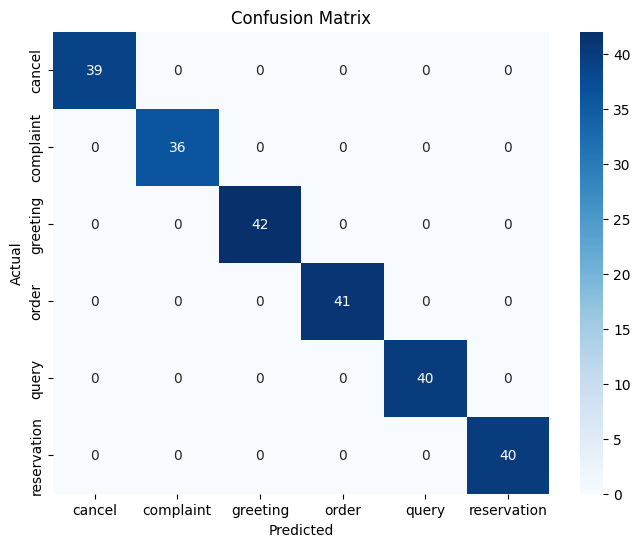

In [23]:
# Confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
# Test
examples = [
    "Hi, can I order two burgers?",
    "Can I reserve a table for four tonight?",
    "What time do you close?",
    "I want to cancel my reservation.",
    "The food was cold and the service was bad.",
    "I want to cancel my table and order takeout instead."
]

for text in examples:
    pred = model.predict([text])[0]
    proba = model.predict_proba([text]).max()
    print(f"Text: {text}")
    print(f"Prediction: {pred} | Confidence: {proba:.2%}")
    print("-" * 60)

Text: Hi, can I order two burgers?
Prediction: order | Confidence: 38.93%
------------------------------------------------------------
Text: Can I reserve a table for four tonight?
Prediction: reservation | Confidence: 94.39%
------------------------------------------------------------
Text: What time do you close?
Prediction: query | Confidence: 22.54%
------------------------------------------------------------
Text: I want to cancel my reservation.
Prediction: cancel | Confidence: 93.40%
------------------------------------------------------------
Text: The food was cold and the service was bad.
Prediction: complaint | Confidence: 83.29%
------------------------------------------------------------
Text: I want to cancel my table and order takeout instead.
Prediction: cancel | Confidence: 82.28%
------------------------------------------------------------
